<a href="https://colab.research.google.com/github/divyanavghare64-jpg/Data-Analytics-Lab/blob/main/Session_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Q1: Create non-linear dataset
from sklearn.datasets import make_moons, make_blobs, load_iris
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)
df_moons = pd.DataFrame(X_moons, columns=['Feature1', 'Feature2'])

print("First 10 rows of dataframe:")
print(df_moons.head(10))
print("Dataset shape:", df_moons.shape)

First 10 rows of dataframe:
   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959
Dataset shape: (500, 2)


In [5]:
# Q2: Scalling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_moons[['Feature1', 'Feature2']])

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])


First 5 scaled rows:
[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


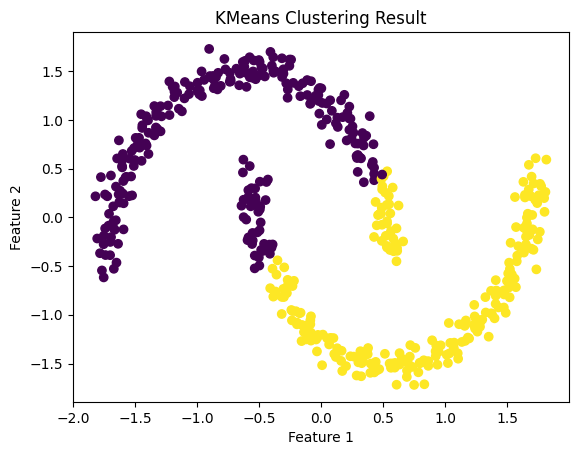

In [6]:
# Q3: K-Means on Non-Linear Data
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df_moons['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df_moons['kmeans_cluster'], cmap='viridis')
plt.title("KMeans Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

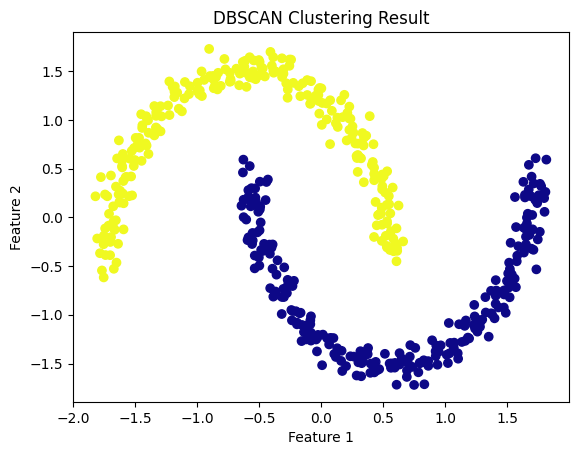

In [7]:
# Q4: DBSCAN Clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_moons['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df_moons['dbscan_cluster'], cmap='plasma')
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
# Q5 Comparing KMeans vs DBSCAN
# Observations:
# 1. KMeans assumes clusters are spherical and uses linear decision boundaries, so it fails on moon-shaped data.
# 2. DBSCAN groups data based on density, making it easy to separate non-linear shapes like half-moons.
# 3. DBSCAN can identify noise points (labeled as -1), whereas KMeans forces every point into a cluster.

In [9]:
# Q6: Tuning DBSCAN Prameters
from sklearn.cluster import DBSCAN
eps_list = [0.2, 0.3, 0.4, 0.5]
results = []

for e in eps_list:
    model = DBSCAN(eps=e, min_samples=5)
    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    results.append({'eps': e, 'number of clusters': n_clusters, 'number of noise points': n_noise})

tuning_df = pd.DataFrame(results)
print(tuning_df)

# Best eps value is 0.3 because it cleanly creates 2 clusters with 0 noise points.

   eps  number of clusters  number of noise points
0  0.2                   2                       0
1  0.3                   2                       0
2  0.4                   2                       0
3  0.5                   2                       0


In [10]:
# Q7: Create high-dimensional dataset
from sklearn.datasets import make_blobs
X_blobs, y_blobs = make_blobs(n_samples=500, n_features=6, centers=4, cluster_std=1.5, random_state=42)
X_blobs_scaled = scaler.fit_transform(X_blobs)

In [11]:
# Q8: Applying PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blobs_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y_blobs

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.64327878 0.21039738]


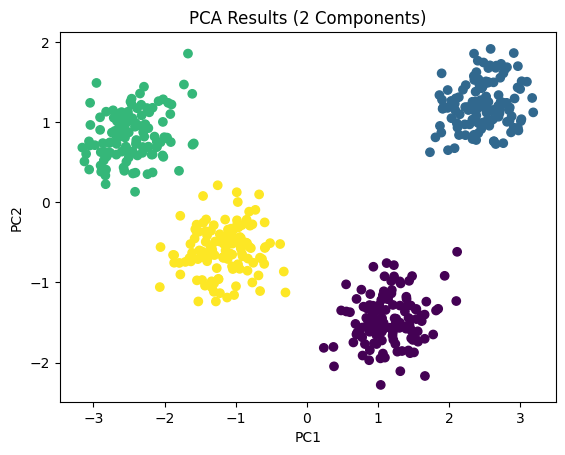

In [12]:

# Q9: Visualizing PCA Results
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['label'])
plt.title("PCA Results (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Q9 Text Answer:
The explained variance ratio shows how much percentage of total variance/information
from 6 original features is kept in PC1 and PC2.


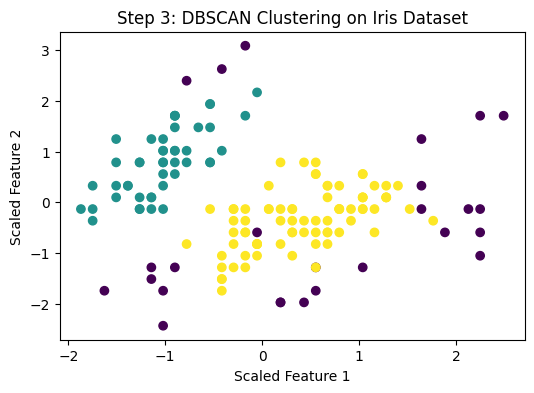

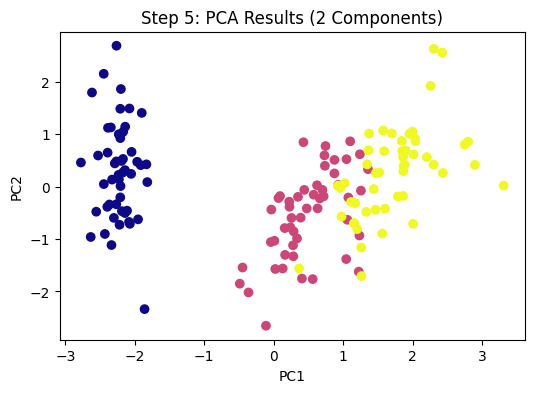

In [13]:
# Q10: Mini Project - Complete Pipeline

# Load and select numerical features (Iris dataset)
iris_data = load_iris()
X_iris = iris_data.data
y_iris = iris_data.target

#  Scale the data
iris_scaler = StandardScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

# Apply DBSCAN and visualize (if possible in 2D)
iris_dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = iris_dbscan.fit_predict(X_iris_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=dbscan_labels, cmap='viridis')
plt.title("Step 3: DBSCAN Clustering on Iris Dataset")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.show()

# Apply PCA to reduce 2 components
iris_pca = PCA(n_components=2)
X_iris_pca = iris_pca.fit_transform(X_iris_scaled)

# Visualize the PCA results
plt.figure(figsize=(6, 4))
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, cmap='plasma')
plt.title("Step 5: PCA Results (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()